In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from matplotlib.ticker import ScalarFormatter
import brainsignals.plotting_convention as pc

plt.rcParams.update({
    "figure.dpi": 600,
    "figure.figsize": (6, 2.5),
    "font.size": 8,
    "mathtext.fontset": "stix"
})

In [2]:
file_path = '/home/tone/work/celltype_ES/CellTypeDependenceElStim/simulations/sim_results/plot_imem_data_ideal.npy'
imem_data = np.load(file_path, allow_pickle=True).item()


In [3]:
# Make subset data dictionary for Im plots
target_freqs = [10, 100, 1000]

scatter_imem_data = {}

for cell_name, cell_data in imem_data.items():
    freqs = np.array(cell_data['freqs'])
    print(freqs)
    # Find indices corresponding to 10, 100, and 1000 Hz
    freq_indices = [np.argmin(np.abs(freqs - f)) for f in target_freqs]
    
    # Extract subsets
    imem_amps_subset = np.array(cell_data['imem_amps'])[:, freq_indices].tolist()
    imem_phases_subset = np.array(cell_data['imem_phases'])[:, freq_indices].tolist()
    pos_avg_subset = [cell_data['positive_avg_imem_pos'][i] for i in freq_indices]
    neg_avg_subset = [cell_data['negative_avg_imem_pos'][i] for i in freq_indices]
    cdm_pos_subset = [cell_data['cdm_pos'][i] for i in freq_indices]
    cdm_neg_subset = [cell_data['cdm_neg'][i] for i in freq_indices]
    
    # Build new dictionary for this cell
    scatter_imem_data[cell_name] = {
        'freqs': [freqs[i] for i in freq_indices],
        'x': cell_data['x'],
        'z': cell_data['z'],
        'totnsegs': cell_data['totnsegs'],
        'tvec': cell_data['tvec'],
        'imem_amps': imem_amps_subset,
        'imem_phases': imem_phases_subset,
        'cdm_pos': cdm_pos_subset,
        'cdm_neg': cdm_neg_subset
    }

[   1    5   10   50  100  500 1000]
[   1    5   10   50  100  500 1000]
[   1    5   10   50  100  500 1000]
[   1    5   10   50  100  500 1000]


[   1    5   10   50  100  500 1000]
BL_-500_UL_1000_SD_20_DD_2 pz at 1 Hz: 0.8527476142045303
BL_-500_UL_1000_SD_20_DD_2 pz at 5 Hz: 0.8392065739616368
BL_-500_UL_1000_SD_20_DD_2 pz at 10 Hz: 0.8005244450685086
0 tab:blue
BL_-500_UL_1000_SD_20_DD_2 pz at 50 Hz: 0.38884527022762316
BL_-500_UL_1000_SD_20_DD_2 pz at 100 Hz: 0.18564693993856152
1 tab:orange
BL_-500_UL_1000_SD_20_DD_2 pz at 500 Hz: 0.009523281010922018
BL_-500_UL_1000_SD_20_DD_2 pz at 1000 Hz: 0.0012533427871735258
2 tab:green
[   1    5   10   50  100  500 1000]
BL_-100_UL_200_SD_20_DD_2 pz at 1 Hz: 0.1541938550611751
BL_-100_UL_200_SD_20_DD_2 pz at 5 Hz: 0.15415355705655587
BL_-100_UL_200_SD_20_DD_2 pz at 10 Hz: 0.1541713343079793
0 tab:blue
BL_-100_UL_200_SD_20_DD_2 pz at 50 Hz: 0.15315455514665924
BL_-100_UL_200_SD_20_DD_2 pz at 100 Hz: 0.15095890486107835
1 tab:orange
BL_-100_UL_200_SD_20_DD_2 pz at 500 Hz: 0.10669236706933362
BL_-100_UL_200_SD_20_DD_2 pz at 1000 Hz: 0.0620811237829932
2 tab:green


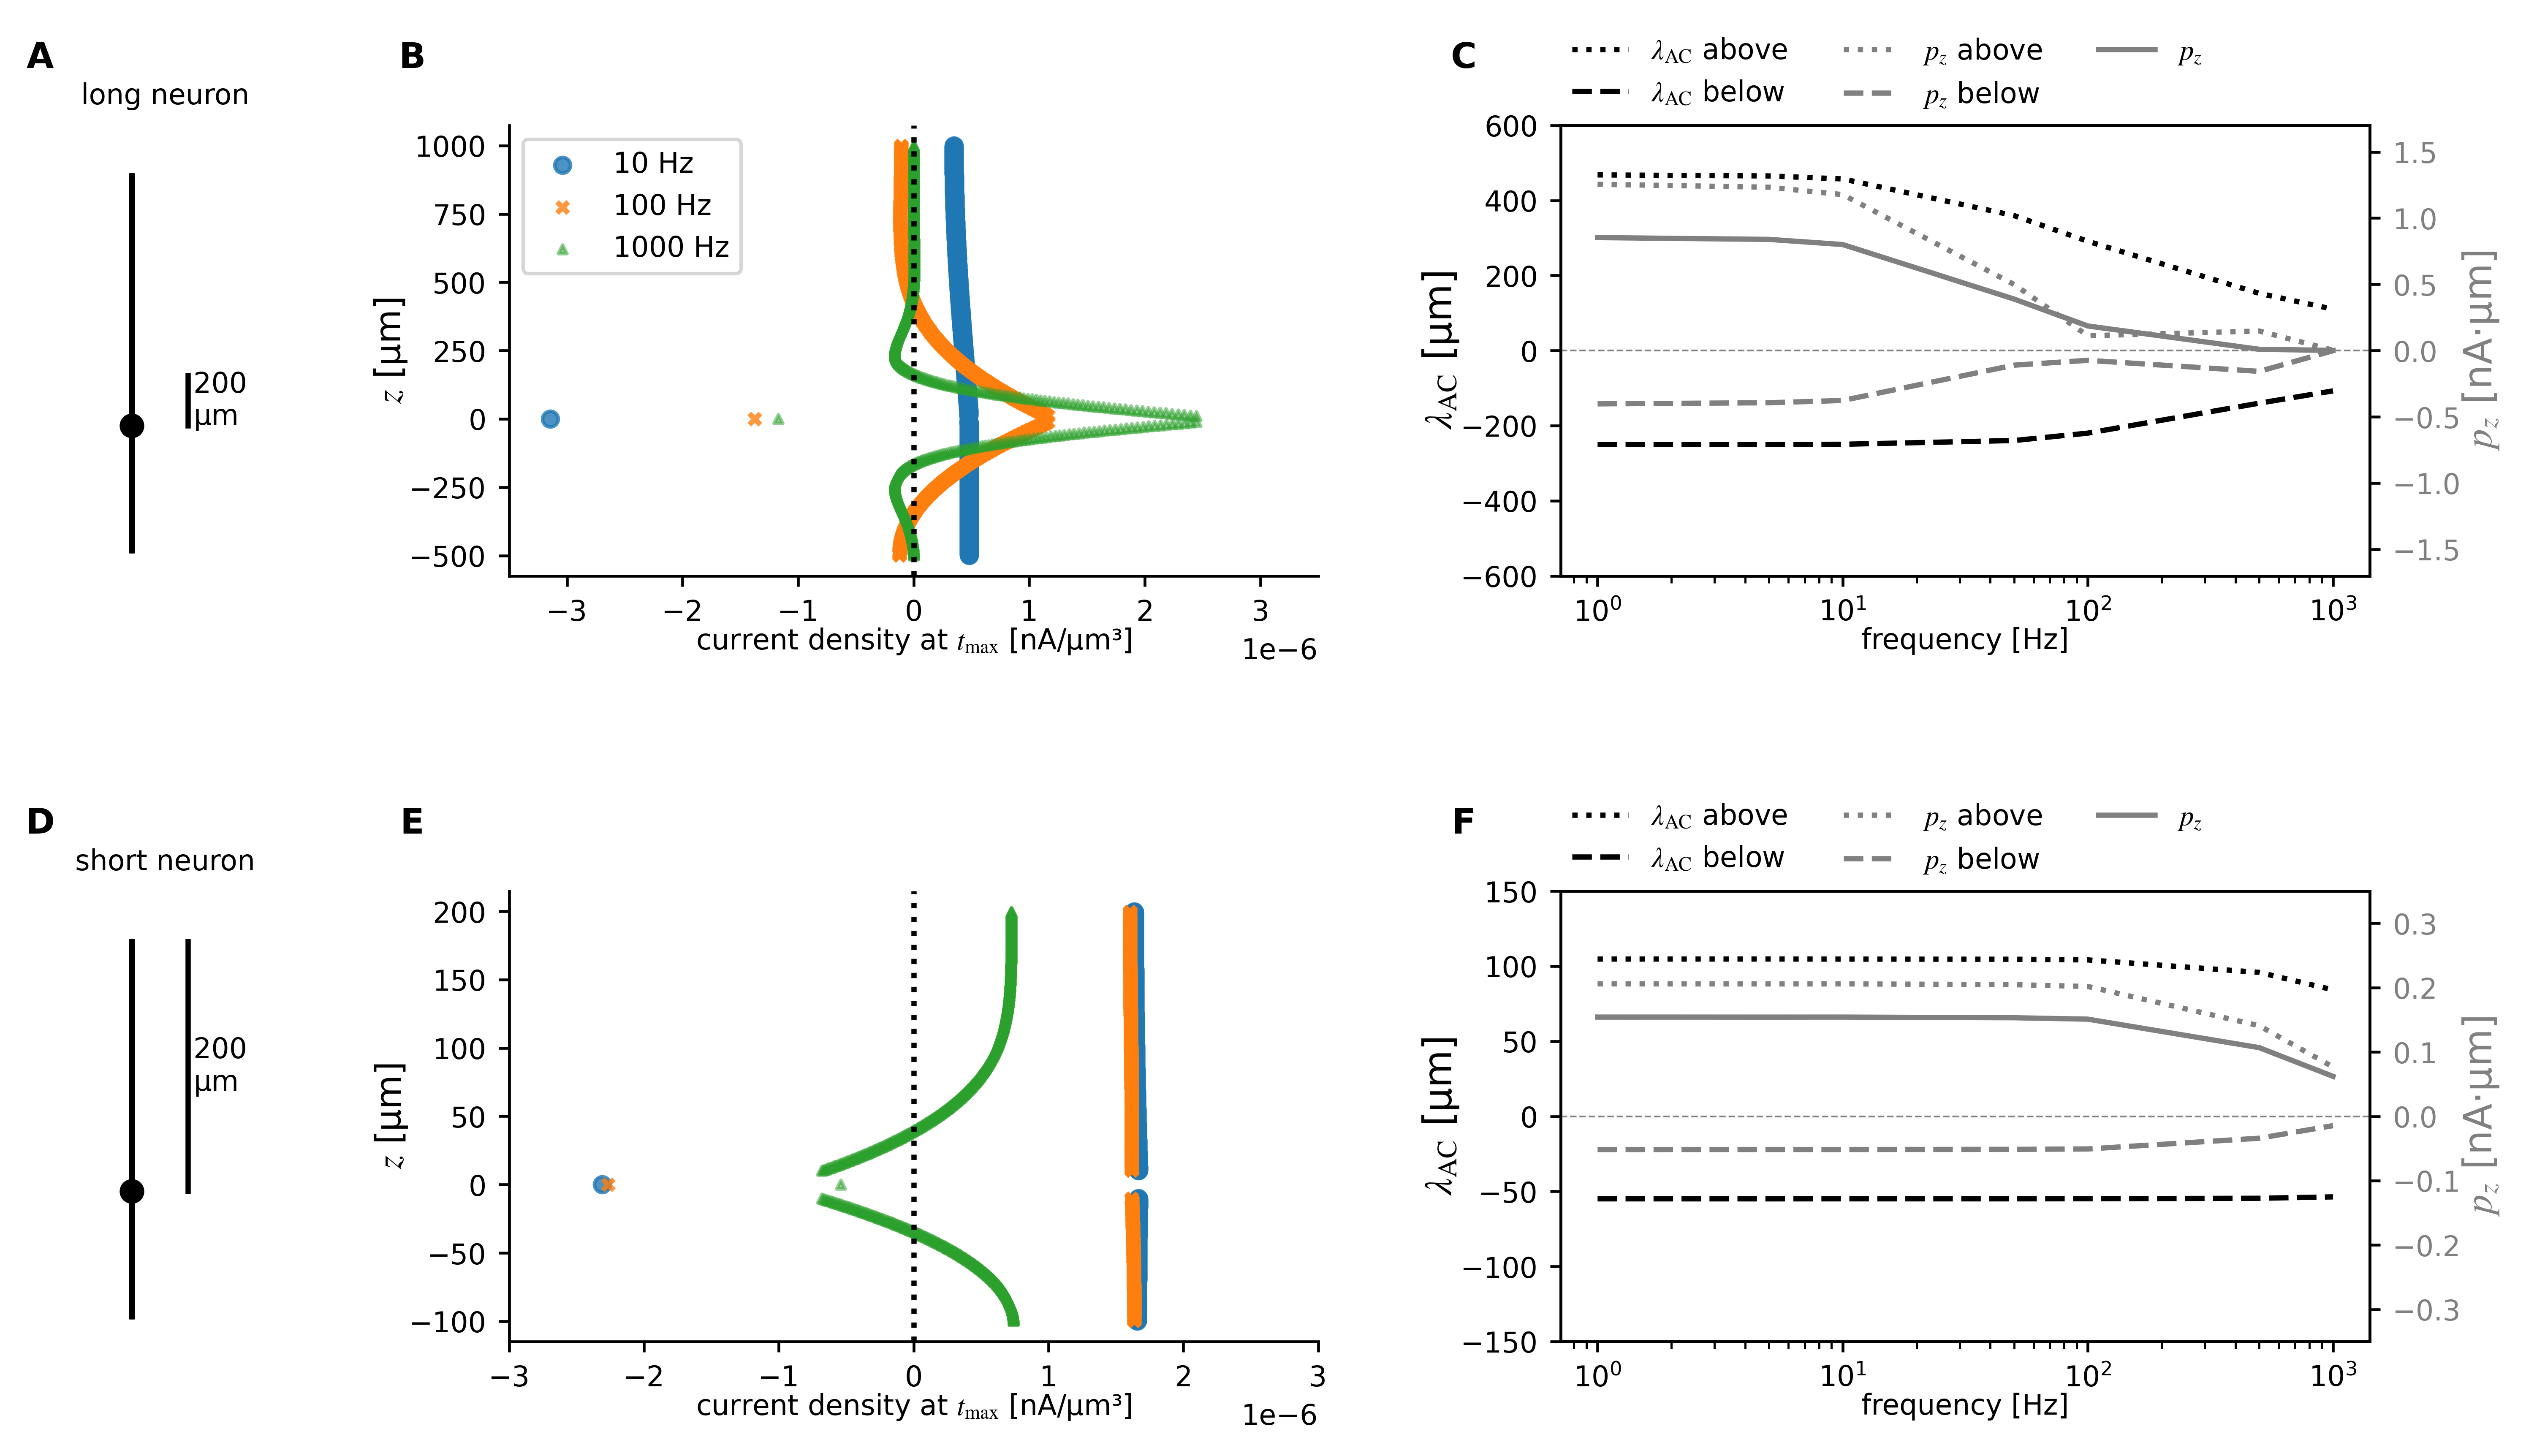

In [6]:

color_neurons = {
    'BL_-500_UL_1000_SD_20_DD_2': 'k',
    'BL_-100_UL_200_SD_20_DD_2': 'k',
    'BL_-200_UL_1000_SD_20_DD_2': 'k',
    'BL_-50_UL_200_SD_20_DD_2': 'k'
}

cell_short_names = {
    'BL_-500_UL_1000_SD_20_DD_2': 'long neuron',
    'BL_-100_UL_200_SD_20_DD_2': 'short neuron',
    'BL_-200_UL_1000_SD_20_DD_2': 'long neuron',
    'BL_-50_UL_200_SD_20_DD_2': 'short neuron',
}

cell_cdm_colors = {
    'BL_-500_UL_1000_SD_20_DD_2': 'gray',
    'BL_-100_UL_200_SD_20_DD_2': 'gray',
    'BL_-200_UL_1000_SD_20_DD_2': 'gray',
    'BL_-50_UL_200_SD_20_DD_2': 'gray',
}

cell_cdm_up_down_colors = {
    'BL_-500_UL_1000_SD_20_DD_2': 'k',
    'BL_-100_UL_200_SD_20_DD_2': 'k',
    'BL_-200_UL_1000_SD_20_DD_2': 'k',
    'BL_-50_UL_200_SD_20_DD_2': 'k',
}

sim_type = "shorter"
sim_type = "longer"

if sim_type == "shorter":
    cell_names = ['BL_-200_UL_1000_SD_20_DD_2', 'BL_-50_UL_200_SD_20_DD_2']
else:
    cell_names = ['BL_-500_UL_1000_SD_20_DD_2', 'BL_-100_UL_200_SD_20_DD_2', ]

cell_xlims_left = {"BL_-100_UL_200_SD_20_DD_2": [-0.3e-5, 0.3e-5],
                   'BL_-50_UL_200_SD_20_DD_2': [-0.25e-5, 0.25e-5],
                   'BL_-200_UL_1000_SD_20_DD_2': [-0.35e-5, 0.35e-5],
                   'BL_-500_UL_1000_SD_20_DD_2': [-0.35e-5, 0.35e-5]
                   }

# cell_xlims_right = {"BL_-100_UL_200_SD_20_DD_2": [-2e-6, 6e-6],
#                    'BL_-500_UL_1000_SD_20_DD_2': [-10e-6, 30e-6],
#                     "BL_-50_UL_200_SD_20_DD_2": [-1e-6, 3e-6],
#                     'BL_-200_UL_1000_SD_20_DD_2': [-0.1e-5, 0.2e-5]
#                     }

pz_ylims = {"BL_-100_UL_200_SD_20_DD_2": [-0.35, 0.35],
                   'BL_-500_UL_1000_SD_20_DD_2': [-1.7, 1.7],
                    "BL_-50_UL_200_SD_20_DD_2": [-0.3, 0.3],
                    'BL_-200_UL_1000_SD_20_DD_2': [-1.6, 1.6]
                    }

lambda_ylims = {"BL_-100_UL_200_SD_20_DD_2": [-150, 150],
                   'BL_-500_UL_1000_SD_20_DD_2': [-600, 600],
                    "BL_-50_UL_200_SD_20_DD_2": [-100, 100],
                    'BL_-200_UL_1000_SD_20_DD_2': [-500, 500]
                    }

plot_freqs = [10, 100, 1000]

# ---- Sub-panels: morphology + two-axis scatter ----
left_ratio = 1.9
middle_ratio = 0.6
right_ratio = 1.2

fig = plt.figure(figsize=(10, 6))
fig.subplots_adjust(left=0.02, right=0.93, bottom=0.10, top=0.9)

gs = gridspec.GridSpec(2, 3, width_ratios=[0.5, 2, 2],
                       height_ratios=[1, 1],
                       wspace=0.4, hspace=0.7)

for row_idx, cell_name in enumerate(cell_names):
    freqs = np.array(imem_data[cell_name]["freqs"])
    print(freqs)
    pz_amps = np.array(imem_data[cell_name]['cdm'])
    pz_phases = np.array(imem_data[cell_name]['cdm_phases'])
    pz_pos_amps = np.array(imem_data[cell_name]['cdm_pos'])
    pz_neg_amps = np.array(imem_data[cell_name]['cdm_neg'])
    pz_pos_phases = np.array(imem_data[cell_name]['cdm_pos_phases'])
    pz_neg_phases = np.array(imem_data[cell_name]['cdm_neg_phases'])

    positive_avrg_imem_pos = np.array(imem_data[cell_name]['positive_avg_imem_pos'])
    negative_avrg_imem_pos = np.array(imem_data[cell_name]['negative_avg_imem_pos'])

    input_phases = imem_data[cell_name]['input_phases']
    input_amps = imem_data[cell_name]['input_amps']

    im_amps = np.array(imem_data[cell_name]['imem_amps'])
    im_phases = np.array(imem_data[cell_name]['imem_phases'])

    x = np.array(imem_data[cell_name]['x'])
    z = np.array(imem_data[cell_name]['z'])
    area = np.array(imem_data[cell_name]['area'])

    zs = np.array(imem_data[cell_name]['z']).mean(axis=1)
    mask = zs != 0

    cell_clr = color_neurons[cell_name]

    ax_m = fig.add_subplot(gs[row_idx, 0], xlim=[np.min(z) * 1.2, np.max(z) * 1.2], frameon=False,
                           xticks=[], yticks=[], ylim=[np.min(z) * 1.2, np.max(z) * 1.2],
                           title=cell_short_names[cell_name])
    ax_m.plot([-np.min(z), -np.min(z)], [0, 200], c='k', clip_on=False)
    ax_m.text(-np.min(z)*1.1, 100, "200 \nµm", ha='left', va="center", clip_on=False)
    ax_m.plot(x.T, z.T, c=cell_clr)
    ax_m.plot(x[0].mean(), z[0].mean(), 'o', c=cell_clr)

    ax_left = fig.add_subplot(gs[row_idx, 1], xlabel=r"current density at $t_{\rm max}$ [nA/µm³]")

    #ax_right = fig.add_subplot(2, 6, row_idx * 6 + 4, sharey=ax_left)

       # --- Axis settings ---
    ax_left.axvline(0, color='black', linestyle=':')
    ax_left.set_ylabel('$z$ [µm]', fontsize=10)

    ax_freq_lambd = fig.add_subplot(gs[row_idx, 2], xlabel="frequency [Hz]")
    ax_freq_pz = ax_freq_lambd.twinx()

    ax_freq_pz.set_ylim(pz_ylims[cell_name])
    ax_freq_lambd.set_ylim(lambda_ylims[cell_name])
    ax_freq_pz.axhline(0, ls='--', lw=0.5, c='gray')


    xlim_left = cell_xlims_left[cell_name]
    #xlim_right = cell_xlims_right[cell_name]

    ax_left.set_xlim(xlim_left)
    # ax_right.set_xlim(xlim_right)

    pz_values = np.zeros(len(freqs))
    pz_pos_values = np.zeros(len(freqs))
    pz_neg_values = np.zeros(len(freqs))
    lines = []
    line_names = []
    for idx, freq in enumerate(freqs):

        f_idx = np.argmin(np.abs(freqs - freq))

        T = 1 / freq * 1000 * 1
        t_ = np.linspace(0, T, 100)

        im_amp = im_amps[:, f_idx]
        input_amp = input_amps[f_idx]
        pz_amp = pz_amps[f_idx]
        pz_pos_amp = pz_pos_amps[f_idx]
        pz_neg_amp = pz_neg_amps[f_idx]

        print(f"{cell_name} pz at {freq} Hz: {pz_amp}")
        imem_pos_neg = negative_avrg_imem_pos[f_idx]
        imem_pos_pos = positive_avrg_imem_pos[f_idx]

        input_phase = input_phases[f_idx]
        pz_phase = pz_phases[f_idx] - input_phase
        pz_pos_phase = pz_pos_phases[f_idx] - input_phase
        pz_neg_phase = pz_neg_phases[f_idx] - input_phase
        im_phase = im_phases[:, f_idx] - input_phase
        input_phase -= input_phase

        pz = pz_amp * np.sin(2 * np.pi * freq * t_ / 1000 + pz_phase)
        pz_pos = pz_pos_amp * np.sin(2 * np.pi * freq * t_ / 1000 + pz_pos_phase)
        pz_neg = pz_neg_amp * np.sin(2 * np.pi * freq * t_ / 1000 + pz_neg_phase)
        input_current = input_amp  * np.sin(2 * np.pi * freq * t_ / 1000 + input_phase)

        t_pz_max_idx = np.argmax(pz)
        t_pz_max = t_[t_pz_max_idx]

        im = np.array([im_amp[c_idx] * np.sin(2 * np.pi * freq * t_ / 1000 + im_phase[c_idx])
                       for c_idx in range(im_amp.shape[0])])
        im_soma = im[0, :].copy()

        im_t_max = im[:, t_pz_max_idx]
        if im_soma[t_pz_max_idx] > 0:
            im_t_max *= -1

        pz_values[idx] = pz[t_pz_max_idx]
        pz_pos_values[idx] = pz_pos[t_pz_max_idx]
        pz_neg_values[idx] = pz_neg[t_pz_max_idx]

        fig_ctrl = plt.figure(figsize=[10, 4])
        ax_stim = fig_ctrl.add_subplot(3, 1, 1)
        ax_im = fig_ctrl.add_subplot(3, 1, 2)
        ax_pz = fig_ctrl.add_subplot(3, 1, 3)

        ax_stim.plot(t_, input_current, c='k')
        ax_im.plot(t_, im_soma / np.std(im_soma), c='b', ls=':')
        l1, = ax_pz.plot(t_, pz / np.std(pz), c=cell_cdm_colors[cell_name], ls='-')
        l2, = ax_pz.plot(t_, pz_pos / np.std(pz_pos), c=cell_cdm_colors[cell_name], ls=':')
        l3, = ax_pz.plot(t_, pz_neg / np.std(pz_neg), c=cell_cdm_colors[cell_name], ls='--')
        ax_pz.legend([l1, l2, l3], ["$p_z$", "$p_z$ above", "$p_z$ below"])

        ax_stim.axvline(t_pz_max, ls='--', c='gray')
        ax_im.axvline(t_pz_max, ls='--', c='gray')
        ax_pz.axvline(t_pz_max, ls='--', c='gray')
        fig_ctrl.savefig(f"ctrl_{cell_name}_{freq}Hz.png", dpi=300)
        plt.close(fig_ctrl)

        # Marker styling unchanged
        if freq == 10:
            marker, size, alpha = 'o', 20, 0.8
        elif freq == 100:
            marker, size, alpha = 'x', 10, 0.8
        else:
            marker, size, alpha = '^', 6, 0.5

        colors = ["tab:blue", "tab:orange", "tab:green"]
        if freq in plot_freqs:
            f_idx_ = np.argmin(np.abs(freq - plot_freqs))
            clr = colors[f_idx_]
            print(f_idx_, clr)
            l = ax_left.scatter(im_t_max / area, zs, marker=marker, s=size, alpha=alpha, c=clr)
            # ax_right.scatter(im_t_max / area, zs, marker=marker, s=size, alpha=alpha)
            lines.append(l)
            line_names.append(f"{freq} Hz")
        #xlim_left = [np.min(im_t_max), np.min(im_t_max) / 2]
        #xlim_right = [np.min([np.min(im_t_max[mask]), 0]), np.max(im_t_max) * 1.2]

    if row_idx == 0:
        ax_left.legend(lines, line_names, loc='upper left', fontsize=8)

    l1, = ax_freq_pz.semilogx(freqs, pz_values, color=cell_cdm_colors[cell_name], ls='-')
    l2, = ax_freq_pz.semilogx(freqs, np.abs(pz_pos_values), color=cell_cdm_colors[cell_name], ls=':')
    l3, = ax_freq_pz.semilogx(freqs, -np.abs(pz_neg_values), color=cell_cdm_colors[cell_name], ls='--')

    l1_, = ax_freq_lambd.semilogx(freqs, positive_avrg_imem_pos, c=cell_clr, ls=':')
    l2_, = ax_freq_lambd.semilogx(freqs, negative_avrg_imem_pos, c=cell_clr, ls='--')

    #ax_freq_lambd.legend([l1_, l2_], [r'$\lambda_{\rm AC}$ above', r'$\lambda_{\rm AC}$ below'])
    ax_freq_pz.legend([ l1_, l2_, l2, l3, l1,],
                      [r'$\lambda_{\rm AC}$ above', r'$\lambda_{\rm AC}$ below', "$p_z$ above", "$p_z$ below","$p_z$" ],
                      ncol=3, frameon=False, loc=(0, 1.01))

    ax_freq_lambd.set_ylabel(r'$\lambda_{\rm AC}$ [µm]', fontsize=11, color=cell_clr)
    ax_freq_lambd.tick_params(axis='y', labelcolor=cell_clr)
    ax_freq_pz.set_ylabel(r'$p_z$ [nA·µm]', fontsize=11, color = cell_cdm_colors[cell_name])
    ax_freq_pz.tick_params(axis='y', labelcolor=cell_cdm_colors[cell_name])

    pc.simplify_axes(ax_left)

    pc.mark_subplots([ax_m, ax_left, ax_freq_pz], [["A", "B", "C"], ["D", "E", "F"]][row_idx])

fig.savefig(f"fig6_R1.pdf")
